# 05 评估与错误分析：指标是目标的翻译

> 前置：`03-probability`（分布与期望）、`02-baselines-tabular`。
> 目标：选对指标、读懂指标、用指标驱动迭代。**评估不是最后一步，而是每一步**——"准确率 0.9"远不如"召回率 0.6、精确率 0.98"信息量大。

## 指标怎么选

| 场景 | 该看的指标 | 为什么 |
|------|-----------|--------|
| 类别均衡的分类 | accuracy | 简单直接 |
| 类别不平衡（欺诈/罕见病） | PR-AUC / F1 / 阈值+PR | accuracy 被多数类绑架 |
| 要排序/打分 | ROC-AUC / PR-AUC | 只关心排序质量 |
| 概率要可信（风控） | Brier / 可靠性图 | 0.8 就该真的 80% 对 |
| 回归 | MAE / RMSE / MAPE | 见本课回归一节 |

原则：**指标必须对应业务目标**。漏检一个欺诈客户赔 100 块、误杀一个正常客户丢 1 块——那你要的是"低阈值 + 高召回"，而不是 accuracy。

In [1]:
# 本模块通用导入（全部 CPU 即可运行）
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.filterwarnings("ignore")

# 中文字体兼容（Windows / macOS）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("numpy", np.__version__, "| pandas", pd.__version__, "| sklearn", sklearn.__version__)

numpy 2.5.2 | pandas 3.0.5 | sklearn 1.9.0


In [2]:
import io, urllib.request

TITANIC_URLS = [
    "https://cdn.jsdelivr.net/gh/datasciencedojo/datasets@master/titanic.csv",
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv",
]

def load_titanic():
    """本地缓存优先，CDN 在线下载兜底；全部失败返回 None（触发下方 sklearn 回退）。"""
    for p in (os.path.join("..", "titanic.csv"), "titanic.csv"):
        if os.path.exists(p):
            return pd.read_csv(p)
    for url in TITANIC_URLS:
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=15) as r:
                data = r.read()
            with open(os.path.join("..", "titanic.csv"), "wb") as f:
                f.write(data)
            return pd.read_csv(io.BytesIO(data))
        except Exception:
            continue
    return None

try:
    df = load_titanic()
    d = df.set_index("PassengerId")
    y = d["Survived"].astype(int); d = d.drop(columns=["Survived"])
    d["Age"] = d["Age"].fillna(d["Age"].median())
    d["Fare"] = d["Fare"].fillna(d["Fare"].median())
    d["Embarked"] = d["Embarked"].fillna(d["Embarked"].mode()[0])
    d = pd.get_dummies(d, columns=["Sex", "Embarked"], drop_first=True)
    X = d[["Pclass", "Age", "Fare", "SibSp", "Parch", "Sex_male", "Embarked_Q", "Embarked_S"]]
except Exception:
    from sklearn.datasets import load_breast_cancer
    Xb, yb = load_breast_cancer(return_X_y=True, as_frame=True)
    X, y = Xb, yb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, brier_score_loss)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
m = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p = m.predict_proba(X_te)[:, 1]
pred = (p >= 0.5).astype(int)

print("准确率 accuracy  = %.4f   （全部预测中对的比例）" % accuracy_score(y_te, pred))
print("精确率 precision = %.4f   （预测为正里真对的）" % precision_score(y_te, pred))
print("召回率 recall    = %.4f   （真实正例里抓到的）" % recall_score(y_te, pred))
print("F1               = %.4f   （精确率与召回率调和平均）" % f1_score(y_te, pred))
print("ROC-AUC          = %.4f   （排序质量，随机=0.5）" % roc_auc_score(y_te, p))
print("PR-AUC           = %.4f   （正类检索质量，不平衡下更敏感）" % average_precision_score(y_te, p))
print("Brier score      = %.4f   （概率可信度，越低越好）" % brier_score_loss(y_te, p))

准确率 accuracy  = 0.8045   （全部预测中对的比例）
精确率 precision = 0.7931   （预测为正里真对的）
召回率 recall    = 0.6667   （真实正例里抓到的）
F1               = 0.7244   （精确率与召回率调和平均）
ROC-AUC          = 0.8443   （排序质量，随机=0.5）
PR-AUC           = 0.7865   （正类检索质量，不平衡下更敏感）
Brier score      = 0.1451   （概率可信度，越低越好）


## 不平衡下为什么看 PR-AUC 而不是 ROC-AUC

ROC-AUC 只依赖**排序**，正负样本比例改变时基本不变——这在类别不平衡时是缺点：99.9% 负类的数据里，AUC 0.9 可能只是"负类排得很好"。

PR-AUC 直接度量**正类的精确率-召回率权衡**，负类比例越高越严格。规则：

- 类别均衡 → 看 ROC-AUC；
- 正类稀少且"抓对正类"是目标 → 看 PR-AUC（Kaggle 的 Porto Seguro / IEEE-Fraud 都用 PR-AUC 或类似指标）。

混淆矩阵：
     预测负  预测正
实际负   98   12
实际正   23   46
TP=46  FP=12  FN=23  TN=98

阈值扫描（默认 0.5 未必最优）：
   阈值      精确率      召回率
  0.1   0.4507   0.9275
  0.3   0.6548   0.7971
  0.5   0.7931   0.6667
  0.7   0.8947   0.4928
  0.9   0.9000   0.1304


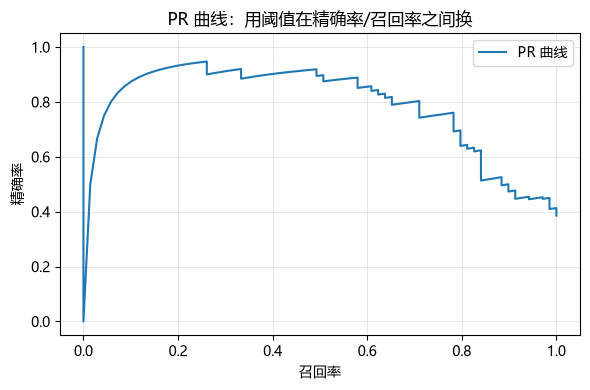

In [3]:
cm = confusion_matrix(y_te, pred)
print("混淆矩阵：")
print(pd.DataFrame(cm, index=["实际负", "实际正"], columns=["预测负", "预测正"]))
tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")

# 阈值扫描：同一模型，不同阈值 = 不同精确率/召回率
print("\n阈值扫描（默认 0.5 未必最优）：")
print(f"{'阈值':>5s} {'精确率':>8s} {'召回率':>8s}")
for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pr = (p >= t).astype(int)
    print(f"{t:5.1f} {precision_score(y_te, pr):8.4f} {recall_score(y_te, pr):8.4f}")

prec, rec, _ = precision_recall_curve(y_te, p)
plt.figure(figsize=(6, 4))
plt.plot(rec, prec, label="PR 曲线")
plt.xlabel("召回率"); plt.ylabel("精确率")
plt.title("PR 曲线：用阈值在精确率/召回率之间换")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 校准：概率要可信

分类器输出 0.8，是说"有 80% 把握"还是"只是相对高分"？**校准（calibration）**度量这个差异。

- **Brier score**：$\frac{1}{n}\sum (p_i - y_i)^2$，越小越好；
- **可靠性图**：按预测概率分箱，画"预测概率 vs 实际正例比例"，越贴对角线越可信；
- 校准方法：Platt scaling（逻辑回归拟合）、Isotonic regression（单调回归）。

注意：**校准改概率绝对值，不改排序**——所以 AUC 几乎不变，但风控/医学场景里概率本身要被消费，校准就重要了。

校准前 Brier = 0.1451   校准后 = 0.1423
校准前 ROC-AUC = 0.8443   校准后 = 0.8468 （AUC 基本不变 → 校准只改概率可信度，不改排序）


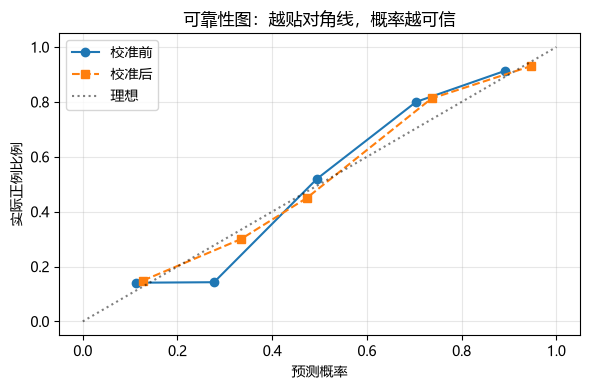

In [4]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

cal = CalibratedClassifierCV(LogisticRegression(max_iter=1000), method="isotonic", cv=5)
cal.fit(X_tr, y_tr)
pc = cal.predict_proba(X_te)[:, 1]
print("校准前 Brier =", round(brier_score_loss(y_te, p), 4),
      "  校准后 =", round(brier_score_loss(y_te, pc), 4))
print("校准前 ROC-AUC =", round(roc_auc_score(y_te, p), 4),
      "  校准后 =", round(roc_auc_score(y_te, pc), 4),
      "（AUC 基本不变 → 校准只改概率可信度，不改排序）")

fop1, mpv1 = calibration_curve(y_te, p, n_bins=5)
fop2, mpv2 = calibration_curve(y_te, pc, n_bins=5)
plt.figure(figsize=(6, 4))
plt.plot(mpv1, fop1, "o-", label="校准前")
plt.plot(mpv2, fop2, "s--", label="校准后")
plt.plot([0, 1], [0, 1], "k:", alpha=0.5, label="理想")
plt.xlabel("预测概率"); plt.ylabel("实际正例比例")
plt.title("可靠性图：越贴对角线，概率越可信")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 回归指标

$$\text{MAE} = \frac{1}{n}\sum |y_i - \hat y_i|, \quad
\text{RMSE} = \sqrt{\frac{1}{n}\sum (y_i - \hat y_i)^2}, \quad
\text{MAPE} = \frac{1}{n}\sum \left|\frac{y_i - \hat y_i}{y_i}\right|$$

- MAE：平均绝对误差，单位直观，对离群点稳健；
- RMSE：平方放大离群点——"大错特错"会被重罚，工程上常用；
- MAPE：百分比误差，跨量级可比，但 $y=0$ 时爆炸。

选哪个看业务：房价预测 Kaggle 用 RMSE，销量预测常用 MAPE。

In [5]:
# 错误分析闭环：模型说错的样本长什么样？
err_df = X_te.copy()
err_df["真实"] = y_te.values
err_df["预测"] = pred
err_df["概率"] = p
wrong = err_df[err_df["真实"] != err_df["预测"]]
print("测试集错误样本：", len(wrong), "/", len(err_df))
print("\n错例（前 8 个）：")
print(wrong.head(8).round(3).to_string())

# 错误模式：按性别×舱位分组统计错误率，定位"模型在哪类人身上最弱"
err_df["Sex_male"] = err_df["Sex_male"].astype(int)
err_df["err"] = (err_df["真实"] != err_df["预测"]).astype(int)
print("\n错误率按（性别, 舱位）分组：")
print(err_df.groupby(["Sex_male", "Pclass"])["err"].mean().round(3).to_string())
print("\n错误分析闭环：定位错因（哪类人、缺什么特征）→ 回特征工程/数据 → 再评估")

测试集错误样本： 35 / 179

错例（前 8 个）：
             Pclass   Age    Fare  SibSp  Parch  Sex_male  Embarked_Q  Embarked_S  真实  预测     概率
PassengerId                                                                                     
554               3  22.0   7.225      0      0      True       False       False   1   0  0.157
560               3  36.0  17.400      1      0     False       False        True   1   0  0.435
280               3  35.0  20.250      1      1     False       False        True   1   0  0.429
713               1  48.0  52.000      1      0      True       False        True   1   0  0.265
456               3  29.0   7.896      0      0      True       False       False   1   0  0.125
66                3  28.0  15.246      1      1      True       False       False   1   0  0.099
490               3   9.0  15.900      1      1      True       False        True   1   0  0.136
870               3   4.0  11.133      1      1      True       False        True   1   0  0.158


## 课后练习（Kaggle）

1. **Porto Seguro 安全驾驶预测**（<https://www.kaggle.com/c/porto-seguro-safe-driver-prediction>）：真实业务是不平衡二分类（正类 ~3.6%），官方评估指标是归一化 Gini（≈ 2×AUC-1）。练习：训练基线 → 报告 ROC-AUC、PR-AUC、归一化 Gini → 用本课阈值扫描选最优阈值。
2. **校准练习**：给上面模型加 isotonic 校准，对比校准前后 Brier score 与可靠性图。
3. **错误分析练习**：对 Titanic（或自选数据）做一次完整错误分析，写 3 条"模型弱点"结论和对应的 3 条改进动作（改特征/加数据/换模型）。